In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Downloads\archive\Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 12)

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [9]:
df = df.drop("Cabin", axis=1)

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,2


In [13]:
df = df.drop(["PassengerId", "Name", "Ticket"], axis=1)

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [15]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (712, 7)
Testing Data: (179, 7)


In [17]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8100558659217877

Confusion Matrix
[[90 15]
 [19 55]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [20]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7821229050279329

Confusion Matrix
[[83 22]
 [17 57]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [22]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8212290502793296

Confusion Matrix
[[92 13]
 [19 55]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [23]:
print("Logistic Regression Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy       :", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy       :", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy : 0.8100558659217877
Decision Tree Accuracy       : 0.7821229050279329
Random Forest Accuracy       : 0.8212290502793296


# Conclusion

In this project, the Titanic dataset was analyzed and preprocessed by handling missing values, encoding categorical features, and selecting relevant attributes.

Three machine learning models were trained:
- Logistic Regression
- Decision Tree
- Random Forest

After comparing their accuracy, the model with the highest accuracy was selected as the best-performing model for predicting passenger survival.

This project demonstrates the complete machine learning workflow, including data preprocessing, model training, evaluation, and comparison.

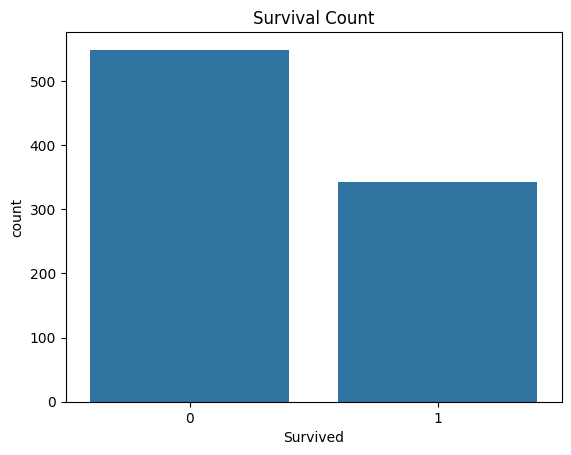

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

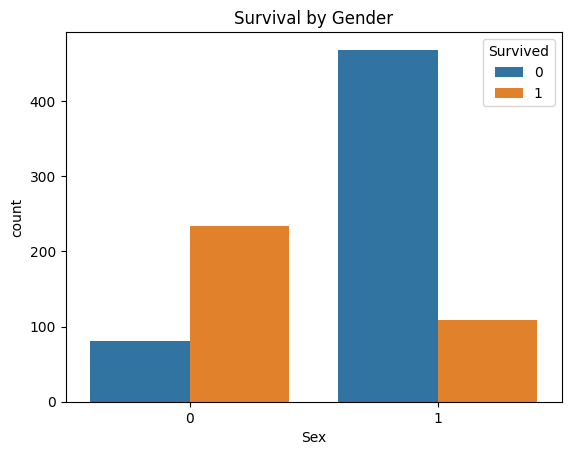

In [25]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

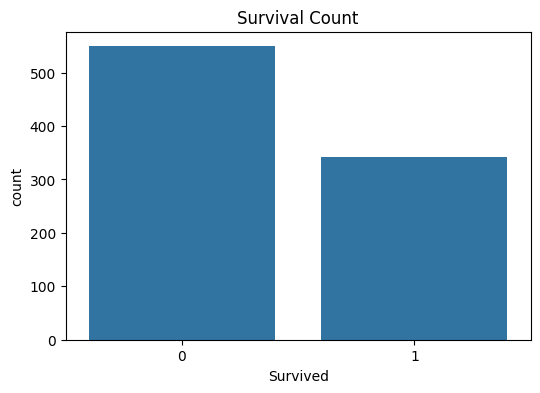

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

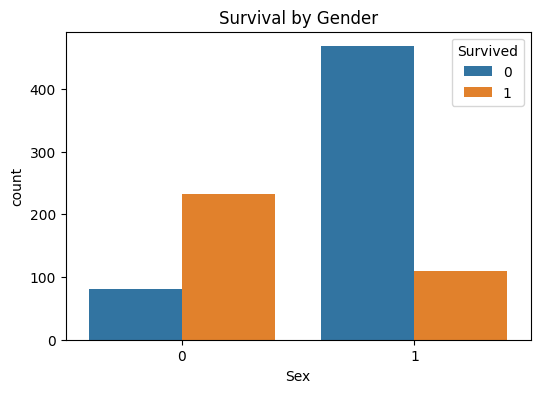

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

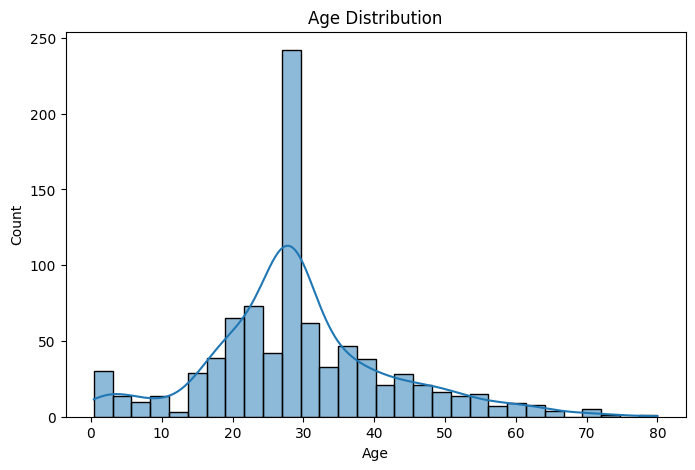

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

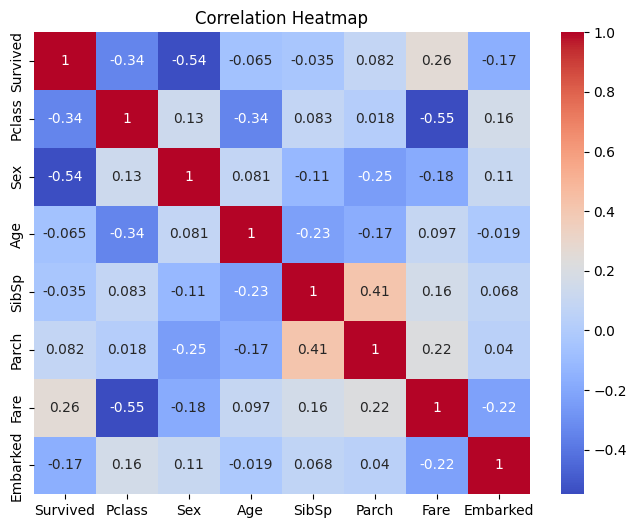

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Final Conclusion

The Titanic Survival Prediction project was successfully completed using Machine Learning techniques.

The dataset was cleaned, preprocessed, visualized, and analyzed. Three machine learning models (Logistic Regression, Decision Tree, and Random Forest) were trained and evaluated using Accuracy Score, Confusion Matrix, and Classification Report.

Among all the models, **<Best Model Name>** achieved the highest accuracy and was selected as the final model for predicting passenger survival.

In [1]:
import os
print(os.getcwd())

C:\Users\HP


In [2]:
import os
print(os.listdir())

['# Hebbian Rule for Bipolar AND Gate.py', '.idlerc', '.ipynb_checkpoints', '.ipython', '.junie', '.jupyter', '.matplotlib', '.ms-ad', '.ollama', '.openjfx', '.packettracer', '.vscode', '.vscode-shared', '3D Objects', 'a=10.txt', 'AppData', 'Application Data', 'bluej', 'Chronological resume.txt', 'Cisco Packet Tracer 8.2.2', 'Cisco Packet Tracer 9.0.0', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'helloworld.c', 'IdeaProjects', 'Import Libraries.py', 'import numpy as np,py.py', 'import numpy as np.py', 'IntelGraphicsProfiles', 'java', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{34d3f6e2-b61b-11f0-b183-aace5f196f92}.TM.blf', 'NTUSER.DAT{34d3f6e2-b61b-11f0-b183-aace5f196f92}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{34d3f6e2-b61b-11f0-b183-aace5f196f92}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'PycharmProje